In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.decomposition import PCA

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.pipeline import Pipeline

from scipy.stats import zscore

import joblib

import warnings
warnings.filterwarnings("ignore")

In [8]:
df = pd.read_csv('/content/mapped_Dataset.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,NaN,Not Mapped,Physician Referral,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,Emergency,Discharged to home,Emergency Room,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,Emergency,Discharged to home,Emergency Room,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,Emergency,Discharged to home,Emergency Room,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,Emergency,Discharged to home,Emergency Room,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [9]:
print(f"Dataset shape: {df.shape}")
print(f"Records: {len(df):,}")
print(f"Features: {df.shape[1]}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (101766, 50)
Records: 101,766
Features: 50

Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [10]:
print(f"\nMissing values:\n{df.isnull().sum()}")


Missing values:
encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id            5291
discharge_disposition_id     3691
admission_source_id          6781
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                    

In [11]:
print(f"\nData types:\n{df.dtypes}")


Data types:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id           object
discharge_disposition_id    object
admission_source_id         object
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepi

In [12]:
columns_to_drop = [
    'encounter_id',
    'patient_nbr',
    'payer_code',
    'discharge_disposition_id',
    'admission_source_id',
    'weight',
    'max_glu_serum',
    'A1Cresult'
]

df = df.drop(columns=columns_to_drop)

In [13]:
age_bins = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
df['age_numeric'] = df['age'].map(age_bins)
df = df.drop(columns=['age'])

In [14]:
top_races = df['race'].value_counts().head(5).index
df['race'] = df['race'].apply(lambda x: x if x in top_races else 'Other')

In [15]:
df['insulin_user'] = (df['insulin'] != 'No').astype(int)

metformin_cols = ['metformin', 'glyburide-metformin', 'glipizide-metformin',
                  'metformin-rosiglitazone', 'metformin-pioglitazone']
df['metformin_user'] = (df[metformin_cols] != 'No').any(axis=1).astype(int)

sulfa_cols = ['glimepiride', 'glipizide', 'glyburide', 'tolbutamide',
              'chlorpropamide', 'tolazamide']
df['sulfonamide_user'] = (df[sulfa_cols] != 'No').any(axis=1).astype(int)

tzd_cols = ['pioglitazone', 'rosiglitazone', 'metformin-rosiglitazone',
            'metformin-pioglitazone']
df['thiazolidinedione_user'] = (df[tzd_cols] != 'No').any(axis=1).astype(int)

med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'examide',
            'citoglipton', 'insulin']
med_count = (df[med_cols] != 'No').sum(axis=1)
df['medication_intensity'] = (med_count / len(med_cols)) * 10

df['medication_changed'] = (df['change'] != 'No').astype(int)

med_to_drop = med_cols + ['glyburide-metformin', 'glipizide-metformin',
                          'glimepiride-pioglitazone', 'metformin-rosiglitazone',
                          'metformin-pioglitazone', 'change', 'diabetesMed']
df = df.drop(columns=med_to_drop)

In [16]:
df['has_diabetes'] = (
    df['diag_1'].astype(str).str[:3].isin(['250']) |
    df['diag_2'].astype(str).str[:3].isin(['250']) |
    df['diag_3'].astype(str).str[:3].isin(['250'])
).astype(int)

df['has_hypertension'] = (
    df['diag_1'].astype(str).str[:3].isin(['401', '402', '403']) |
    df['diag_2'].astype(str).str[:3].isin(['401', '402', '403']) |
    df['diag_3'].astype(str).str[:3].isin(['401', '402', '403'])
).astype(int)

df['has_renal_disease'] = (
    df['diag_1'].astype(str).str[:3].isin(['580', '581', '582', '583', '584', '585']) |
    df['diag_2'].astype(str).str[:3].isin(['580', '581', '582', '583', '584', '585']) |
    df['diag_3'].astype(str).str[:3].isin(['580', '581', '582', '583', '584', '585'])
).astype(int)

df['has_heart_disease'] = (
    df['diag_1'].astype(str).str[:3].isin(['410', '411', '412', '413', '414']) |
    df['diag_2'].astype(str).str[:3].isin(['410', '411', '412', '413', '414']) |
    df['diag_3'].astype(str).str[:3].isin(['410', '411', '412', '413', '414'])
).astype(int)

df['comorbidity_count'] = (
    df['has_hypertension'] + df['has_renal_disease'] + df['has_heart_disease']
)

df = df.drop(columns=['diag_1', 'diag_2', 'diag_3'])

In [17]:
admission_mapping = {
    '1': 'Emergency', '2': 'Urgent', '3': 'Elective',
    '5': 'Newborn', '7': 'Trauma'
}
df['admission_type'] = df['admission_type_id'].astype(str).map(admission_mapping)
df['admission_type'] = df['admission_type'].astype('category')
df['is_emergency'] = (df['admission_type'] == 'Emergency').astype(int)
df = df.drop(columns=['admission_type_id'])

In [18]:
missing_pct = df['medical_specialty'].isna().sum() / len(df) * 100

if missing_pct > 30:
    df = df.drop(columns=['medical_specialty'])
else:
    top_specs = df['medical_specialty'].value_counts().head(10).index
    df['medical_specialty'] = df['medical_specialty'].apply(
        lambda x: x if x in top_specs else 'Other'
    )
    df['medical_specialty'] = df['medical_specialty'].astype('category')

In [19]:
def create_complexity_index(df):
    num_med = df['num_medications'].fillna(0)
    num_proc = df['num_procedures'].fillna(0)
    los = df['time_in_hospital'].fillna(0)
    num_diag = df['number_diagnoses'].fillna(0)
    med_intensity = df['medication_intensity'].fillna(0)

    num_med_norm = num_med / (num_med.max() + 1)
    num_proc_norm = num_proc / (num_proc.max() + 1)
    los_norm = los / (los.max() + 1)
    num_diag_norm = num_diag / (num_diag.max() + 1)
    med_intensity_norm = med_intensity / 10

    df['patient_complexity'] = (
        0.25 * num_med_norm +
        0.15 * num_proc_norm +
        0.20 * los_norm +
        0.20 * num_diag_norm +
        0.20 * med_intensity_norm
    ) * 100

    return df

df = create_complexity_index(df)

In [20]:
def classify_engagement(row):
    outpt = row['number_outpatient']
    emerg = row['number_emergency']
    inpt = row['number_inpatient']

    if outpt > 5 and emerg < 1 and inpt < 1:
        return 'Preventive_Engaged'
    elif emerg > 2 or inpt > 2:
        return 'Acute_High_Risk'
    elif outpt > 2 and emerg + inpt > 1:
        return 'Mixed_Moderate'
    else:
        return 'Low_Engagement'

df['engagement_pattern'] = df.apply(classify_engagement, axis=1)
df['engagement_pattern'] = df['engagement_pattern'].astype('category')
df['total_recent_visits'] = (df['number_outpatient'] +
                              df['number_emergency'] +
                              df['number_inpatient'])

In [21]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

categorical_cols = df.select_dtypes(include='category').columns
for col in categorical_cols:
    if 'Unknown' not in df[col].cat.categories:
        df[col] = df[col].cat.add_categories('Unknown')
df[categorical_cols] = df[categorical_cols].fillna('Unknown')

print(df.isna().sum())

race                      0
gender                    0
time_in_hospital          0
medical_specialty         0
num_lab_procedures        0
num_procedures            0
num_medications           0
number_outpatient         0
number_emergency          0
number_inpatient          0
number_diagnoses          0
readmitted                0
age_numeric               0
insulin_user              0
metformin_user            0
sulfonamide_user          0
thiazolidinedione_user    0
medication_intensity      0
medication_changed        0
has_diabetes              0
has_hypertension          0
has_renal_disease         0
has_heart_disease         0
comorbidity_count         0
admission_type            0
is_emergency              0
patient_complexity        0
engagement_pattern        0
total_recent_visits       0
dtype: int64


In [22]:
# @title
def select_k_best(df_input, y, k=15):
    df_encoded = df_input.copy()

    non_numeric_cols = df_encoded.select_dtypes(include=['object', 'category']).columns

    for col in non_numeric_cols:
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(df_encoded, y)

    scores = pd.DataFrame({
        'Feature': df_encoded.columns,
        'Score': selector.scores_
    }).sort_values('Score', ascending=False)

    return df_input[scores.head(k)['Feature'].tolist()], scores

y = LabelEncoder().fit_transform(df['readmitted'])

X_selected, scores = select_k_best(df.drop(columns=['readmitted']), y, k=15)
print(scores.head(15))

                Feature        Score
9      number_inpatient  2963.323843
27  total_recent_visits  2419.060564
26   engagement_pattern  1084.199942
10     number_diagnoses   655.464952
8      number_emergency   573.257193
7     number_outpatient   355.232693
2      time_in_hospital   170.330886
25   patient_complexity   160.766145
3     medical_specialty   147.855583
6       num_medications   136.749211
12         insulin_user   117.760507
17   medication_changed   108.138659
5        num_procedures   103.541267
20    has_renal_disease    97.875254
4    num_lab_procedures    80.210718


In [23]:
numeric_features = X_selected.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
X_scaled = X_selected.copy()
X_scaled[numeric_features] = scaler.fit_transform(X_selected[numeric_features])

print(X_scaled[numeric_features].describe())

       number_inpatient  total_recent_visits  number_diagnoses  \
count      1.017660e+05         1.017660e+05      1.017660e+05   
mean      -2.115583e-17         4.133417e-17      1.988509e-16   
std        1.000005e+00         1.000005e+00      1.000005e+00   
min       -5.032762e-01        -5.248168e-01     -3.321596e+00   
25%       -5.032762e-01        -5.248168e-01     -7.357332e-01   
50%       -5.032762e-01        -5.248168e-01      2.986119e-01   
75%        2.885790e-01         3.478712e-01      8.157845e-01   
max        1.612568e+01         3.438270e+01      4.435992e+00   

       number_emergency  number_outpatient  time_in_hospital  \
count      1.017660e+05       1.017660e+05      1.017660e+05   
mean       3.044206e-17       2.010851e-17      5.082986e-17   
std        1.000005e+00       1.000005e+00      1.000005e+00   
min       -2.126202e-01      -2.914615e-01     -1.137649e+00   
25%       -2.126202e-01      -2.914615e-01     -8.026506e-01   
50%       -2.126202e-

In [24]:
print(f"Final shape: {X_selected.shape}")
print(f"\nData types:\n{X_selected.dtypes}")
print(f"\nMissing values:\n{X_selected.isna().sum()}")
print(f"\nFeature summary:\n{X_selected.describe()}")
print(f"\nCategorical values:\n{X_selected.select_dtypes('category').nunique()}")

Final shape: (101766, 15)

Data types:
number_inpatient          int64
total_recent_visits       int64
engagement_pattern     category
number_diagnoses          int64
number_emergency          int64
number_outpatient         int64
time_in_hospital          int64
patient_complexity      float64
medical_specialty      category
num_medications           int64
insulin_user              int64
medication_changed        int64
num_procedures            int64
has_renal_disease         int64
num_lab_procedures        int64
dtype: object

Missing values:
number_inpatient       0
total_recent_visits    0
engagement_pattern     0
number_diagnoses       0
number_emergency       0
number_outpatient      0
time_in_hospital       0
patient_complexity     0
medical_specialty      0
num_medications        0
insulin_user           0
medication_changed     0
num_procedures         0
has_renal_disease      0
num_lab_procedures     0
dtype: int64

Feature summary:
       number_inpatient  total_recent_visits

### Optimal Number of Clusters

To determine the optimal number of clusters for the dataset, we will employ two common methods:

1.  **Elbow Method**: This method looks at the total within-cluster sum of squares (WCSS) as a function of the number of clusters. The 'elbow' point in the plot, where the rate of decrease in WCSS sharply changes, is often considered a good indicator of the optimal number of clusters.
2.  **Silhouette Score**: The silhouette score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). It ranges from -1 to 1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters. A higher average silhouette score across all objects suggests better-defined clusters.

In [25]:
categorical_features = X_scaled.select_dtypes(include='category').columns

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded_categorical = encoder.fit_transform(X_scaled[categorical_features])

X_encoded_categorical_df = pd.DataFrame(
    X_encoded_categorical,
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_scaled.index
)

X_processed = pd.concat([X_scaled.drop(columns=categorical_features), X_encoded_categorical_df], axis=1)

print(f"Shape of X_processed: {X_processed.shape}")
print(f"First 5 rows of X_processed:\n{X_processed.head()}")

Shape of X_processed: (101766, 28)
First 5 rows of X_processed:
   number_inpatient  total_recent_visits  number_diagnoses  number_emergency  \
0         -0.503276            -0.524817         -3.321596          -0.21262   
1         -0.503276            -0.524817          0.815784          -0.21262   
2          0.288579             0.784215         -0.735733          -0.21262   
3         -0.503276            -0.524817         -0.218561          -0.21262   
4         -0.503276            -0.524817         -1.252906          -0.21262   

   number_outpatient  time_in_hospital  patient_complexity  num_medications  \
0          -0.291461         -1.137649           -2.433089        -1.848268   
1          -0.291461         -0.467653           -0.287836         0.243390   
2           1.286748         -0.802651            0.217422        -0.371804   
3          -0.291461         -0.802651           -0.539250        -0.002688   
4          -0.291461         -1.137649           -1.374939  

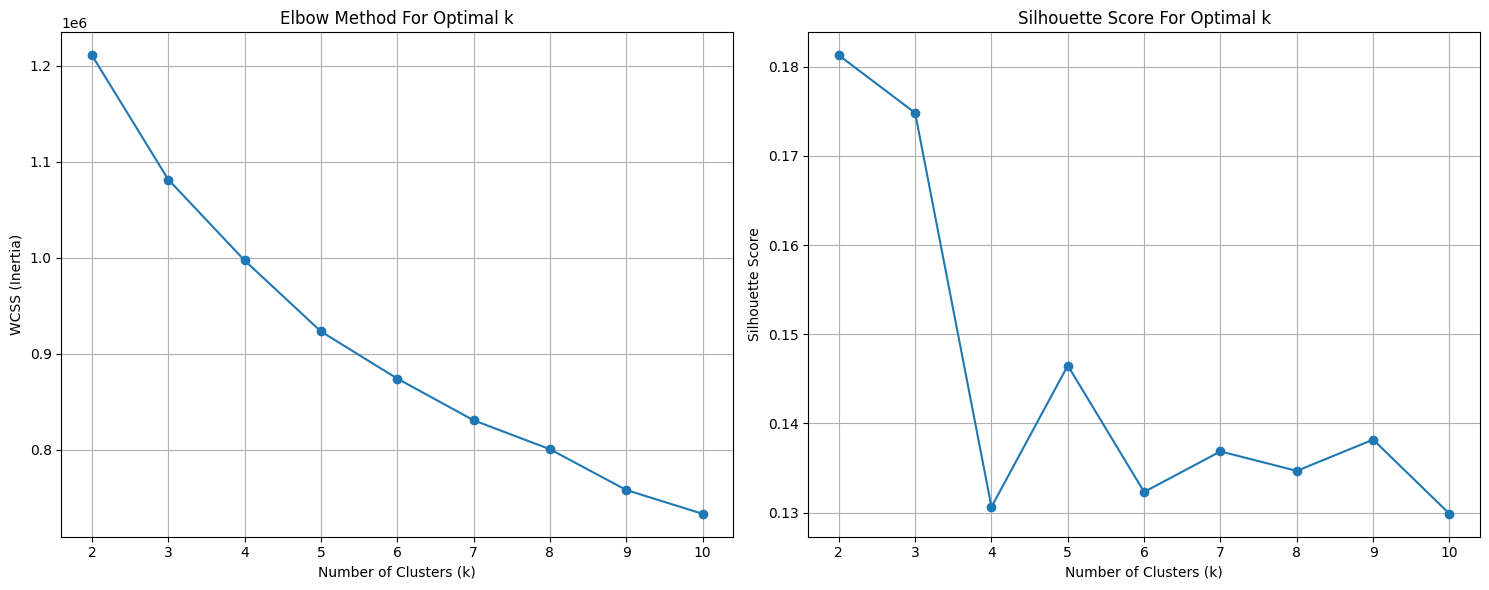

In [26]:
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, kmeans.labels_, n_jobs=-1))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(k_range, wcss, marker='o')
axes[0].set_title('Elbow Method For Optimal k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].grid(True)

axes[1].plot(k_range, silhouette_scores, marker='o')
axes[1].set_title('Silhouette Score For Optimal k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Based on the Elbow Method and Silhouette Score plots:

*   **Elbow Method**: The 'elbow' appears to be around **k=3 or k=4**, where the decrease in WCSS starts to slow down significantly.
*   **Silhouette Score**: The silhouette score is highest at **k=2**, but remains relatively high for k=3 and k=4, suggesting reasonable cluster separation.

Considering both plots, **k=3 or k=4** seems like a reasonable choice for the number of clusters. Let's proceed with `k=3` as a starting point, as it provides a good balance and is often a good compromise between model complexity and interpretability.

In [27]:
optimal_k = 3
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_model.fit(X_processed)

df['cluster'] = kmeans_model.labels_
display(df.head())

,race,gender,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,has_hypertension,has_renal_disease,has_heart_disease,comorbidity_count,admission_type,is_emergency,patient_complexity,engagement_pattern,total_recent_visits,cluster
0,Caucasian,Female,1,Other,41,0,1,0,0,0,...,0,0,0,0,Unknown,0,2.814682,Low_Engagement,0,1
1,Caucasian,Female,3,?,59,0,18,0,0,0,...,0,0,0,0,Unknown,0,21.187151,Low_Engagement,0,1
2,AfricanAmerican,Female,2,?,11,5,13,2,0,1,...,0,0,0,0,Unknown,0,25.514302,Low_Engagement,3,1
3,Caucasian,Male,2,?,44,1,16,0,0,0,...,1,0,0,1,Unknown,0,19.033978,Low_Engagement,0,1
4,Caucasian,Male,1,?,51,0,8,0,0,0,...,0,0,0,0,Unknown,0,11.876933,Low_Engagement,0,1


### Interpreting the Clusters

To interpret the characteristics of each cluster, we will examine the average values of the features within each cluster.

In [28]:
numeric_cols_selected = X_selected.select_dtypes(include=[np.number]).columns
cluster_summary_numeric = df.groupby('cluster')[numeric_cols_selected].mean()
display(cluster_summary_numeric)


,number_inpatient,total_recent_visits,number_diagnoses,number_emergency,number_outpatient,time_in_hospital,patient_complexity,num_medications,insulin_user,medication_changed,num_procedures,has_renal_disease,num_lab_procedures
cluster,,,,,,,,,,,,,
0,0.453707,0.769736,8.320481,0.107111,0.208918,7.012094,33.006243,23.003884,0.716654,0.650625,2.436150,0.116995,52.703107
1,0.337393,0.622374,6.851362,0.088756,0.196225,3.029169,18.758691,12.232108,0.425427,0.354924,0.836293,0.049770,37.901412
2,3.242210,6.549248,8.116256,1.234910,2.072129,4.441708,23.858484,17.085640,0.628786,0.521355,0.898235,0.157660,44.423077


In [29]:
categorical_cols_selected = X_selected.select_dtypes(include=['category']).columns

for col in categorical_cols_selected:
    print(f"\nDistribution of '{col}' across clusters:")
    display(pd.crosstab(df['cluster'], df[col], normalize='index'))


Distribution of 'engagement_pattern' across clusters:


engagement_pattern,Acute_High_Risk,Low_Engagement,Mixed_Moderate,Preventive_Engaged
cluster,,,,
0,0.024504,0.974769,0.000568,0.000158
1,0.011671,0.988198,0.000131,0.000000
2,0.705382,0.171824,0.089780,0.033014



Distribution of 'medical_specialty' across clusters:


medical_specialty,?,Cardiology,Emergency/Trauma,Family/GeneralPractice,InternalMedicine,Nephrology,Orthopedics,Orthopedics-Reconstructive,Other,Radiologist,Surgery-General
cluster,,,,,,,,,,,
0,0.501453,0.057187,0.077523,0.059713,0.134331,0.018883,0.014305,0.011305,0.080870,0.014020,0.030409
1,0.473457,0.053858,0.071963,0.080401,0.151970,0.012311,0.014970,0.013690,0.086277,0.010456,0.030647
2,0.569405,0.028329,0.079102,0.070930,0.122358,0.028873,0.003813,0.004467,0.056984,0.006428,0.029309


Based on the cluster summary, we can start to interpret what each cluster represents:

*   **Cluster 0:** This cluster seems to represent patients with **moderate complexity and higher instances of renal disease**. They have moderate total recent visits and emergency visits. A significant portion of these patients (`~50%`) have an 'Other' medical specialty or missing medical specialty information (`?`), and `~97%` exhibit a 'Low_Engagement' pattern, suggesting they might not be actively seeking care or are managed outside of frequent hospital visits.

*   **Cluster 1:** This cluster appears to be characterized by **lower patient complexity, fewer medications, and less frequent hospital interactions**. They have the lowest number of inpatient, emergency, and outpatient visits, and lower total recent visits. A very high proportion (`~99%`) show a 'Low_Engagement' pattern, and a high percentage also have missing medical specialty information (`~47%`). They also have the lowest rate of insulin use and medication changes, implying less aggressive medical management or fewer comorbidities.

*   **Cluster 2:** This cluster stands out for **high patient complexity, frequent hospitalizations, and a high risk profile**. Patients in this cluster have significantly higher numbers of inpatient, emergency, and total recent visits. A large majority (`~70%`) show an 'Acute_High_Risk' engagement pattern, indicating frequent critical interventions. They also have higher insulin use and medication changes, suggesting more complex and actively managed medical conditions. While a substantial portion has missing medical specialty information (`~57%`), `Cardiology`, `Emergency/Trauma`, and `InternalMedicine` are more prominent than in other clusters. This cluster also has the highest rate of renal disease.

In [30]:
df['is_readmitted'] = df['readmitted'].apply(lambda x: 0 if x == 'NO' else 1)

readmission_rates = df.groupby('cluster')['is_readmitted'].mean().reset_index()
readmission_rates['readmission_rate_pct'] = (readmission_rates['is_readmitted'] * 100).round(2)

display(readmission_rates[['cluster', 'readmission_rate_pct']])

,cluster,readmission_rate_pct
0,0,47.17
1,1,41.53
2,2,72.61


### Visualizing Cluster Characteristics (k=3)

Let's visualize the distribution of key features across the three clusters using box plots to gain a better understanding of each cluster's characteristics.

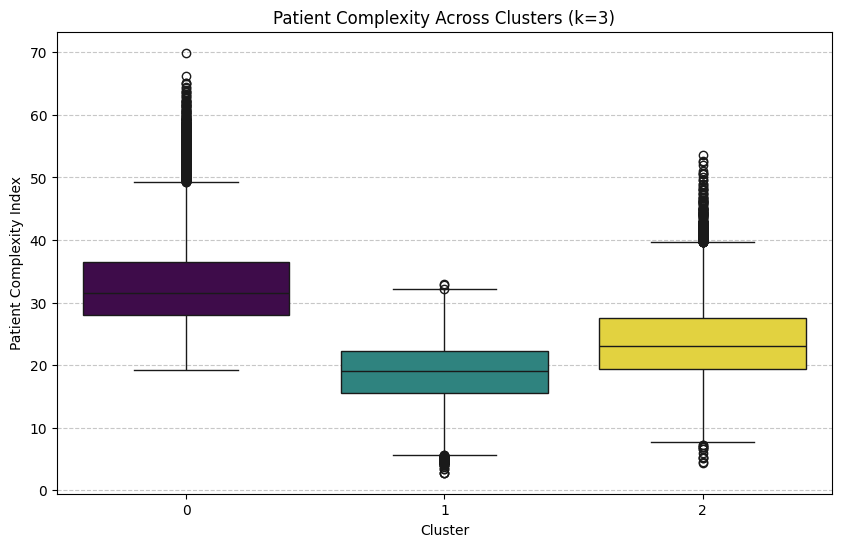

In [31]:
if 'cluster_k4' in df.columns:
    df = df.drop(columns=['cluster_k4'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='patient_complexity', data=df, palette='viridis', hue='cluster', legend=False)
plt.title('Patient Complexity Across Clusters (k=3)')
plt.xlabel('Cluster')
plt.ylabel('Patient Complexity Index')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

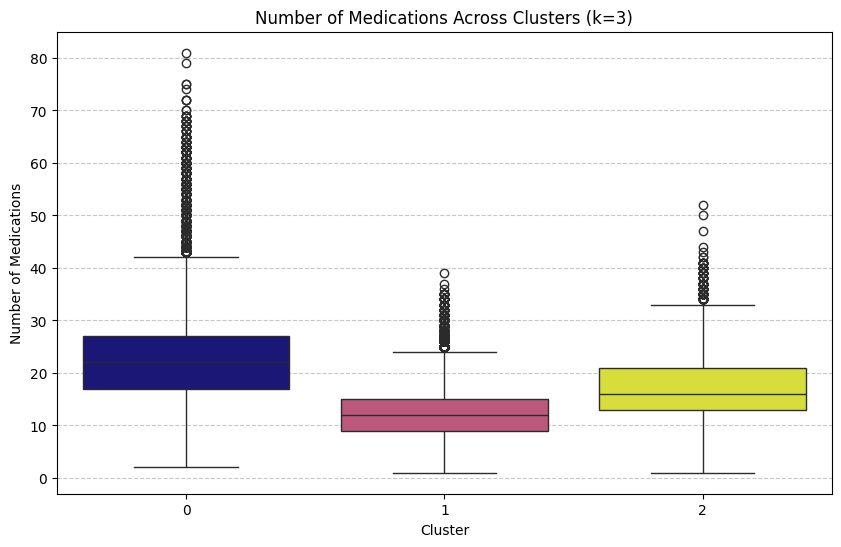

In [32]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='num_medications', data=df, palette='plasma', hue='cluster', legend=False)
plt.title('Number of Medications Across Clusters (k=3)')
plt.xlabel('Cluster')
plt.ylabel('Number of Medications')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

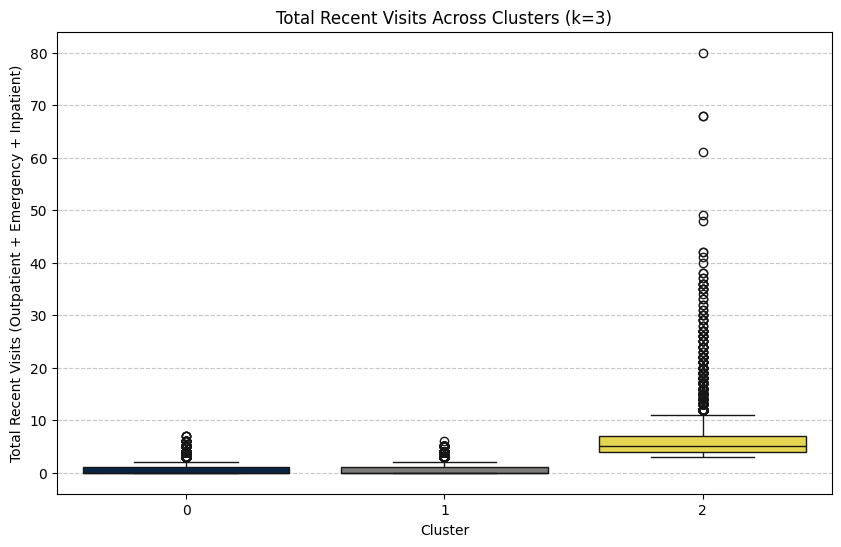

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='total_recent_visits', data=df, palette='cividis', hue='cluster', legend=False)
plt.title('Total Recent Visits Across Clusters (k=3)')
plt.xlabel('Cluster')
plt.ylabel('Total Recent Visits (Outpatient + Emergency + Inpatient)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

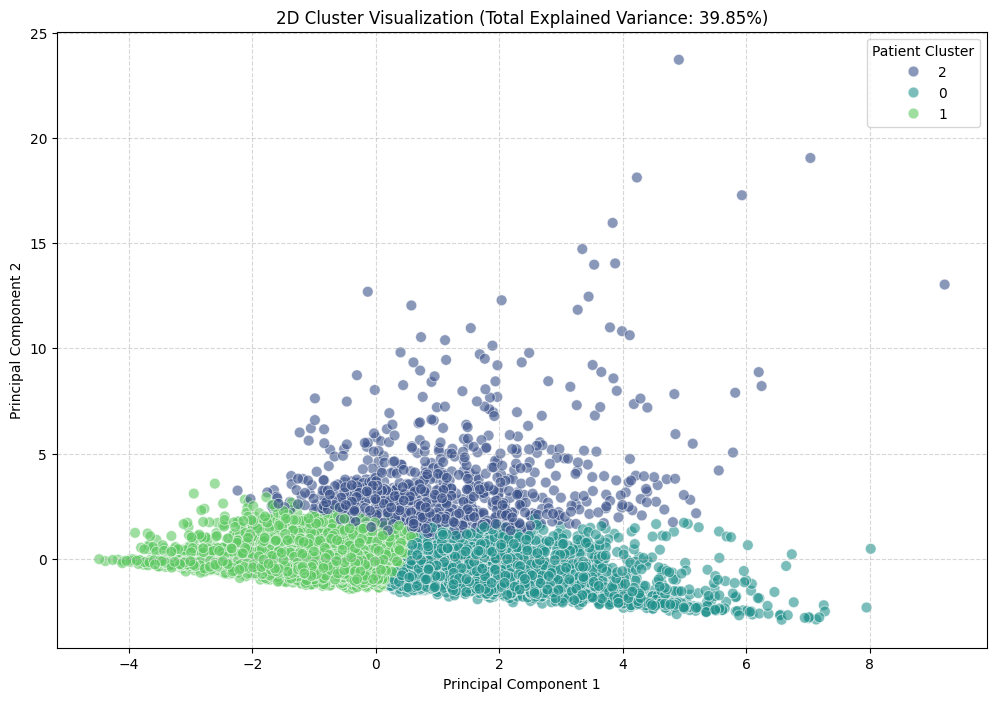

Variance explained by PC1: 22.63%
Variance explained by PC2: 17.23%


In [34]:
pca_2d = PCA(n_components=2)

components_2d = pca_2d.fit_transform(X_processed)

plot_df = pd.DataFrame(components_2d, columns=['PC1', 'PC2'])
plot_df['cluster'] = df['cluster'].astype(str)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=plot_df.sample(10000),
    x='PC1', y='PC2',
    hue='cluster',
    palette='viridis',
    alpha=0.6,
    edgecolor='w',
    s=60
)

explained_var = pca_2d.explained_variance_ratio_.sum()
plt.title(f'2D Cluster Visualization (Total Explained Variance: {explained_var:.2%})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Patient Cluster')
plt.show()

print(f"Variance explained by PC1: {pca_2d.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca_2d.explained_variance_ratio_[1]:.2%}")

In [35]:
sample_plot_df = df.sample(5000, random_state=42)

pca_3d = PCA(n_components=3)
components = pca_3d.fit_transform(X_processed.loc[sample_plot_df.index])

sample_plot_df['PC1'] = components[:, 0]
sample_plot_df['PC2'] = components[:, 1]
sample_plot_df['PC3'] = components[:, 2]
sample_plot_df['cluster'] = sample_plot_df['cluster'].astype(str)

fig = px.scatter_3d(
    sample_plot_df,
    x='PC1', y='PC2', z='PC3',
    color='cluster',
    title='Interactive 3D Healthcare Patient Clusters',
    labels={'PC1': 'Variance 1', 'PC2': 'Variance 2', 'PC3': 'Variance 3'},
    hover_data={
        'patient_complexity': ':.2f',
        'total_recent_visits': True,
        'engagement_pattern': True,
        'age_numeric': True,
        'PC1': False, 'PC2': False, 'PC3': False
    },
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Prism,
    template='plotly_dark'
)

fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=50),
    legend=dict(title_text='Patient Segment', yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

### Cluster Profiling Table

In [63]:
cluster_profile_data = {
    'Metric': ['Avg Total Recent Visits', 'Avg Medications', 'Readmission Rate', 'Avg Complexity Score'],
    'Cluster 0': [
        cluster_summary_numeric.loc[0, 'total_recent_visits'].round(2),
        cluster_summary_numeric.loc[0, 'num_medications'].round(2),
        readmission_rates.loc[readmission_rates['cluster'] == 0, 'readmission_rate_pct'].values[0],
        cluster_summary_numeric.loc[0, 'patient_complexity'].round(2)
    ],
    'Cluster 1': [
        cluster_summary_numeric.loc[1, 'total_recent_visits'].round(2),
        cluster_summary_numeric.loc[1, 'num_medications'].round(2),
        readmission_rates.loc[readmission_rates['cluster'] == 1, 'readmission_rate_pct'].values[0],
        cluster_summary_numeric.loc[1, 'patient_complexity'].round(2)
    ],
    'Cluster 2': [
        cluster_summary_numeric.loc[2, 'total_recent_visits'].round(2),
        cluster_summary_numeric.loc[2, 'num_medications'].round(2),
        readmission_rates.loc[readmission_rates['cluster'] == 2, 'readmission_rate_pct'].values[0],
        cluster_summary_numeric.loc[2, 'patient_complexity'].round(2)
    ]
}

cluster_profile_df = pd.DataFrame(cluster_profile_data)

markdown_table = cluster_profile_df.to_markdown(index=False)
print(markdown_table)

| Metric                  |   Cluster 0 |   Cluster 1 |   Cluster 2 |
|:------------------------|------------:|------------:|------------:|
| Avg Total Recent Visits |        0.77 |        0.62 |        6.55 |
| Avg Medications         |       23    |       12.23 |       17.09 |
| Readmission Rate        |       47.17 |       41.53 |       72.61 |
| Avg Complexity Score    |       33.01 |       18.76 |       23.86 |
